### IMPORTS

In [1]:
import os
import numpy as numpy
import matplotlib.pyplot as plot
import seaborn as seaborn
import tensorflow as tensorflow
import pandas as pandas
import json
import glob
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tqdm import tqdm

### SET PARAMETERS

In [2]:
image_height = 224
image_width = 224
test_directory = "../data/brain_tumor/testing"
dropout_passes = 5
batch_size = 32
saved_directory = "../saved"

### LOAD MODEL & CLASS NAMES

In [3]:
trained_model = tensorflow.keras.models.load_model(
    os.path.join(saved_directory, "resnet_model.h5"))

with open(os.path.join(saved_directory, "class_names.json"), "r") as file_input:
    label_names = json.load(file_input)

### LOAD RESULTS DATAFRAME

In [4]:
results_table = pandas.read_csv(os.path.join(saved_directory, "results_dataframe.csv"))
final_prediction_array = numpy.load(os.path.join(saved_directory, "final_preds.npy"))

### HELPER FUNCTIONS

In [5]:
def load_image(image_path):
    pil_image = load_img(image_path, target_size=(image_height, image_width))
    image_array = img_to_array(pil_image)
    image_array = preprocess_input(image_array)
    expanded_array = numpy.expand_dims(image_array, axis=0)
    return pil_image, expanded_array

def load_image_preprocessed(image_path):
    pil_image = load_img(image_path, target_size=(image_height, image_width))
    image_array = img_to_array(pil_image)
    image_array = preprocess_input(image_array)
    expanded_array = numpy.expand_dims(image_array, axis=0)
    return pil_image, expanded_array

### GRAD MODEL FOR ACTIVATIONS

In [6]:
base_model = trained_model.get_layer("resnet50")
conv_layer = base_model.get_layer("conv5_block3_out")

conv_output_model = tensorflow.keras.Model(
    inputs=base_model.input,
    outputs=conv_layer.output)

grad_model = tensorflow.keras.Model(
    inputs=trained_model.input,
    outputs=[conv_output_model(trained_model.input), trained_model.output])

### ACTIVATION vs COVERAGE

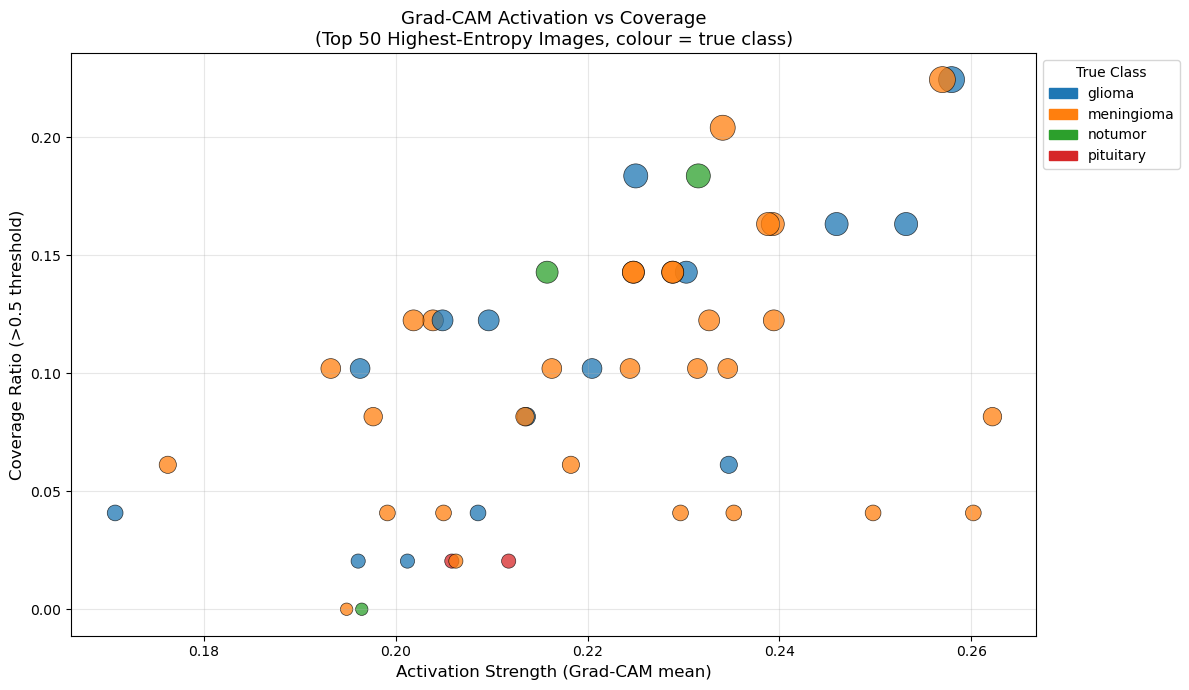

In [7]:
# Use file paths directly from results_table to guarantee correct entropy alignment
top_count = 50
if 'entropy' in results_table.columns:
    top_rows = results_table.sort_values('entropy', ascending=False).head(top_count)
else:
    top_rows = results_table.head(top_count)

top_image_paths = top_rows['file'].values

all_heatmaps = []
for image_path in top_image_paths:
    _, expanded_tensor = load_image_preprocessed(image_path)
    expanded_tensor = tensorflow.convert_to_tensor(expanded_tensor)
    conv_output, _ = grad_model(expanded_tensor, training=False)
    conv_output = conv_output[0].numpy()
    heatmap = numpy.mean(conv_output, axis=-1)
    all_heatmaps.append(heatmap)

global_minimum = min(h.min() for h in all_heatmaps)
global_maximum = max(h.max() for h in all_heatmaps)

activation_values = []
coverage_values = []
true_class_labels = top_rows['true'].values

for heatmap in all_heatmaps:
    normalized_heatmap = (heatmap - global_minimum) / (global_maximum - global_minimum + 1e-10)
    activation_values.append(numpy.mean(normalized_heatmap))
    coverage_values.append(numpy.mean(normalized_heatmap > 0.5))

import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Create fixed color mapping that matches label order exactly
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # tab10 colors
class_color_map = {label_names[i]: color_palette[i] for i in range(len(label_names))}
point_colors = [class_color_map[c] for c in true_class_labels]

plot.figure(figsize=(12, 7))
bubble_sizes = (numpy.array(coverage_values) * 1200) + 80
scatter = plot.scatter(
    activation_values,
    coverage_values,
    s=bubble_sizes,
    c=point_colors,
    alpha=0.75,
    edgecolors='black',
    linewidth=0.5)

# Create legend handles that match the color_palette exactly
handles = [mpatches.Patch(color=color_palette[i], label=label_names[i]) 
           for i in range(len(label_names))]
plot.legend(handles=handles, title='True Class', loc='upper left', bbox_to_anchor=(1, 1))
plot.xlabel('Activation Strength (Grad-CAM mean)', fontsize=12)
plot.ylabel('Coverage Ratio (>0.5 threshold)', fontsize=12)
plot.title('Grad-CAM Activation vs Coverage\n(Top 50 Highest-Entropy Images, colour = true class)', fontsize=13)
plot.grid(alpha=0.3)
plot.tight_layout()
plot.show()

### MISCLASSIFICATIONS

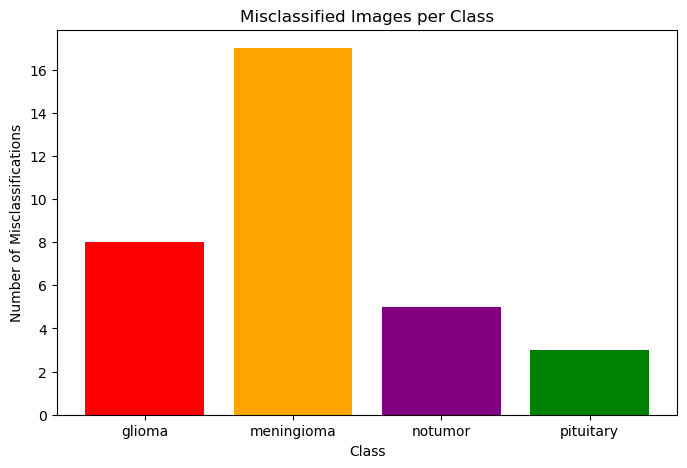

In [8]:
misclassified_counts = (
    results_table[results_table["true"] != results_table["pred"]]
    .groupby("true")
    .size())
plot.figure(figsize=(8, 5))
plot.bar(
    misclassified_counts.index,
    misclassified_counts.values,
    color=["red", "orange", "purple", "green"])
plot.title("Misclassified Images per Class")
plot.xlabel("Class")
plot.ylabel("Number of Misclassifications")
plot.show()

### MC-DROPOUT FUNCTION

In [9]:
def mc_predict(model_network, image_batch, dropout_passes=5):
    prediction_collection = []
    for pass_index in range(dropout_passes):
        prediction_values = model_network(image_batch, training=True).numpy()
        prediction_collection.append(prediction_values)

    prediction_stack = numpy.stack(prediction_collection, axis=0)
    mean_predictions = prediction_stack.mean(axis=0)
    variance_predictions = prediction_stack.var(axis=0)
    return mean_predictions, variance_predictions

### ALIGNMENT

In [10]:
results_table = results_table.sort_values("file").reset_index(drop=True)
sorted_file_paths = results_table["file"].tolist()

sorted_image_tensor = numpy.stack([load_image(path)[1][0] for path in sorted_file_paths], axis=0)

mean_prediction_list = []
for batch_start_index in tqdm(range(0, len(sorted_image_tensor), batch_size)):
    batch_end_index = min(batch_start_index + batch_size, len(sorted_image_tensor))
    image_batch = sorted_image_tensor[batch_start_index:batch_end_index]
    mean_batch_predictions, _ = mc_predict(trained_model, image_batch, dropout_passes)
    mean_prediction_list.extend(mean_batch_predictions)

predicted_probabilities = numpy.array(mean_prediction_list)
true_labels = [label_names.index(name) for name in results_table["true"]]
true_labels_binary = label_binarize(true_labels, classes=range(len(label_names)))

100%|███████████████████████████████████████████| 41/41 [08:44<00:00, 12.80s/it]


### MULTI-CLASS ROC

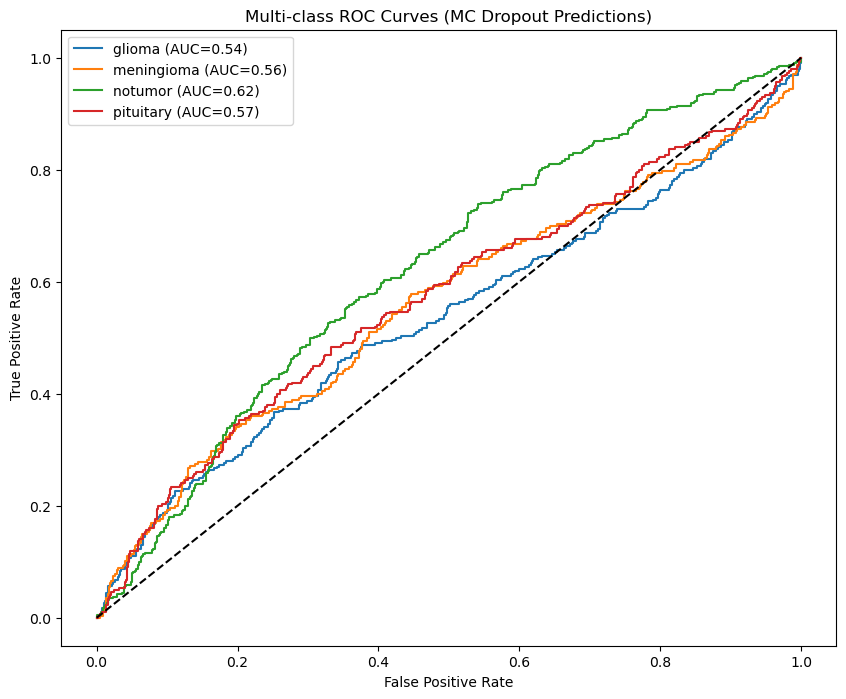

In [11]:
plot.figure(figsize=(10, 8))
for class_index, class_name in enumerate(label_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        true_labels_binary[:, class_index],
        predicted_probabilities[:, class_index])
    roc_auc_value = auc(false_positive_rate, true_positive_rate)
    plot.plot(false_positive_rate, true_positive_rate, label=f"{class_name} (AUC={roc_auc_value:.2f})")

plot.plot([0, 1], [0, 1], "k--")
plot.title("Multi-class ROC Curves (MC Dropout Predictions)")
plot.xlabel("False Positive Rate")
plot.ylabel("True Positive Rate")
plot.legend()
plot.show()

### MULTI-CLASS PRECISION-RECALL

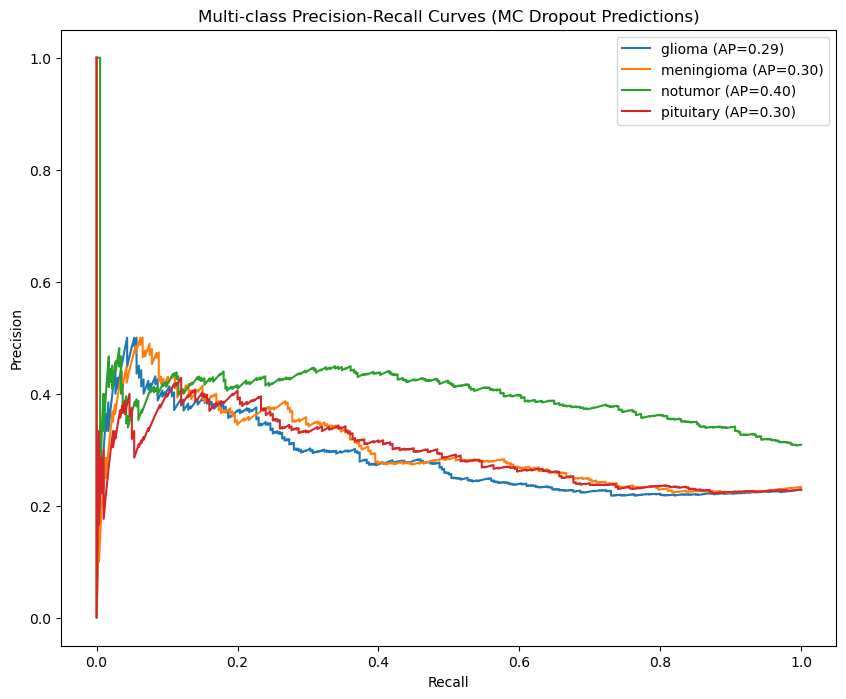

In [12]:
plot.figure(figsize=(10, 8))
for class_index, class_name in enumerate(label_names):
    precision_values, recall_values, _ = precision_recall_curve(
        true_labels_binary[:, class_index],
        predicted_probabilities[:, class_index])
    average_precision = average_precision_score(
        true_labels_binary[:, class_index],
        predicted_probabilities[:, class_index])
    plot.plot(recall_values, precision_values, label=f"{class_name} (AP={average_precision:.2f})")
plot.title("Multi-class Precision-Recall Curves (MC Dropout Predictions)")
plot.xlabel("Recall")
plot.ylabel("Precision")
plot.legend()
plot.show()

### TTA UNCERTAINTY HEATMAP

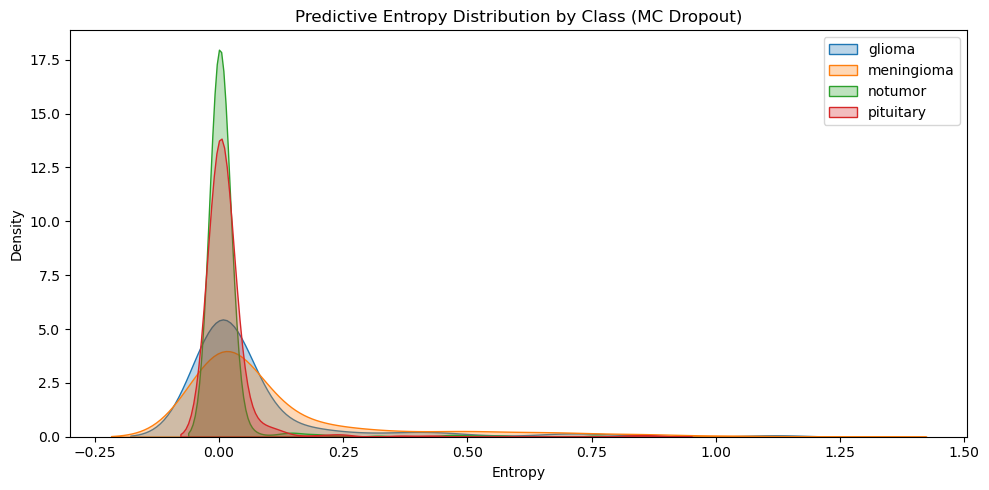

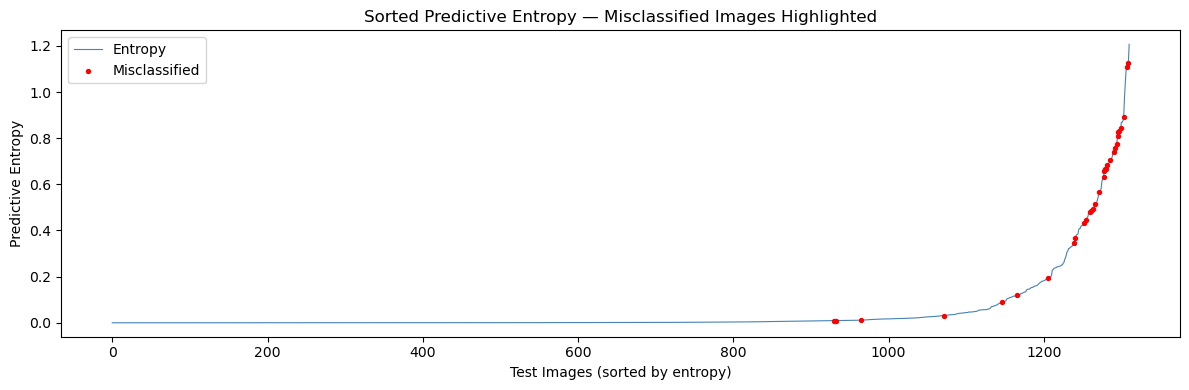

In [13]:
plot.figure(figsize=(10, 5))
for class_name in label_names:
    class_entropy = results_table[results_table['true'] == class_name]['entropy']
    seaborn.kdeplot(class_entropy, label=class_name, fill=True, alpha=0.3)
plot.title('Predictive Entropy Distribution by Class (MC Dropout)')
plot.xlabel('Entropy')
plot.ylabel('Density')
plot.legend()
plot.tight_layout()
plot.show()

sorted_df = results_table.sort_values('entropy').reset_index(drop=True)
correct_mask = sorted_df['true'].values == sorted_df['pred'].values

plot.figure(figsize=(12, 4))
plot.plot(sorted_df['entropy'].values, color='steelblue', linewidth=0.8, label='Entropy')
plot.scatter(
    numpy.where(~correct_mask)[0],
    sorted_df['entropy'].values[~correct_mask],
    color='red', s=8, label='Misclassified', zorder=5)
plot.title('Sorted Predictive Entropy — Misclassified Images Highlighted')
plot.xlabel('Test Images (sorted by entropy)')
plot.ylabel('Predictive Entropy')
plot.legend()
plot.tight_layout()
plot.show()